In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

aapl = pd.read_csv('AAPL_historical_data.csv')
aapl['Date'] = pd.to_datetime(aapl['Date'])
aapl = aapl.sort_values('Date')

aapl.head()

/tmp/ipython-input-2510740520.py:11: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  aapl['Date'] = pd.to_datetime(aapl['Date'])


,Date,Open,High,Low,Close
0,1980-12-12 00:00:00-05:00,0.098834,0.099264,0.098834,0.098834
1,1980-12-15 00:00:00-05:00,0.094108,0.094108,0.093678,0.093678
2,1980-12-16 00:00:00-05:00,0.087232,0.087232,0.086802,0.086802
3,1980-12-17 00:00:00-05:00,0.088951,0.089381,0.088951,0.088951
4,1980-12-18 00:00:00-05:00,0.091530,0.091959,0.091530,0.091530


Using Adjusted Close column for price predictions
Normalization of data

In [3]:
data = aapl['Close'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range =(0,1))
scaled_data = scaler.fit_transform(data)

In [4]:
def aapl_sequences(data, seq_length=60):
  X, y = [], []
  for i in range(seq_length, len(data)):
    X.append(data[i-seq_length:i, 0])
    y.append(data[i, 0])
  return np.array(X), np.array(y)

In [5]:
SEQ_LENGTH = 60 #setting sequence length to 60 days of historical data to predict the next day
X, y = aapl_sequences(scaled_data, SEQ_LENGTH)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Sequence shape: {X_train.shape}")

Training samples: 8827
Testing samples: 2207
Sequence shape: (8827, 60, 1)


LSTM Model - Stock Price Prediction

In [6]:
#Model build
aapl_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(SEQ_LENGTH, 1)),  # Down from 100
    Dropout(0.2),
    LSTM(25, return_sequences=False),  # Down from 100
    Dropout(0.2),
    Dense(1)  # Removed extra Dense layer
])

aapl_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
aapl_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 25)             │         7,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,026 (70.41 KB)

 Trainable params: 18,026 (70.41 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
#Model training
history = aapl_model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=50,
    validation_split=0.1,
    verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7
        )
    ]
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - loss: 1.1853e-04 - mae: 0.0062 - val_loss: 1.1803e-05 - val_mae: 0.0026 - learning_rate: 0.0010
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 4.6954e-06 - mae: 0.0010 - val_loss: 1.5317e-05 - val_mae: 0.0031 - learning_rate: 0.0010
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 3.7505e-06 - mae: 9.4009e-04 - val_loss: 1.3028e-05 - val_mae: 0.0029 - learning_rate: 0.0010
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 3.1281e-06 - mae: 9.2256e-04 - val_loss: 2.4184e-05 - val_mae: 0.0040 - learning_rate: 0.0010
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - loss: 4.0192e-06 - mae: 0.0011 - val_loss: 1.6284e-05 - val_mae: 0.0033 - learning_rate: 0.0010
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - loss: 3.6835e-06 - mae: 0.0011 - val_loss: 1.5456e-05 - val_mae: 0.0032 - learning_rate: 0.0010
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 3.3260e-06 - mae: 9.8036e-04 - val

In [8]:
#Prediction Training
train_predictions = aapl_model.predict(X_train)
test_predictions = aapl_model.predict(X_test)

train_predictions = scaler.inverse_transform(train_predictions)
test_predictions = scaler.inverse_transform(test_predictions)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))



276/276 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


Metrics

In [9]:
def calculate_metrics(actual, predicted, set_name):
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    print(f"\n{set_name} Metrics:")
    print(f"RMSE: ${rmse:.2f}")
    print(f"MAE: ${mae:.2f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"Accuracy: {100 - mape:.2f}%")

    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

train_metrics = calculate_metrics(y_train_actual, train_predictions, "Training")
test_metrics = calculate_metrics(y_test_actual, test_predictions, "Testing")


Training Metrics:
RMSE: $0.28
MAE: $0.13
R² Score: 0.9983
MAPE: 12.91%
Accuracy: 87.09%

Testing Metrics:
RMSE: $5.58
MAE: $3.71
R² Score: 0.9924
MAPE: 3.32%
Accuracy: 96.68%


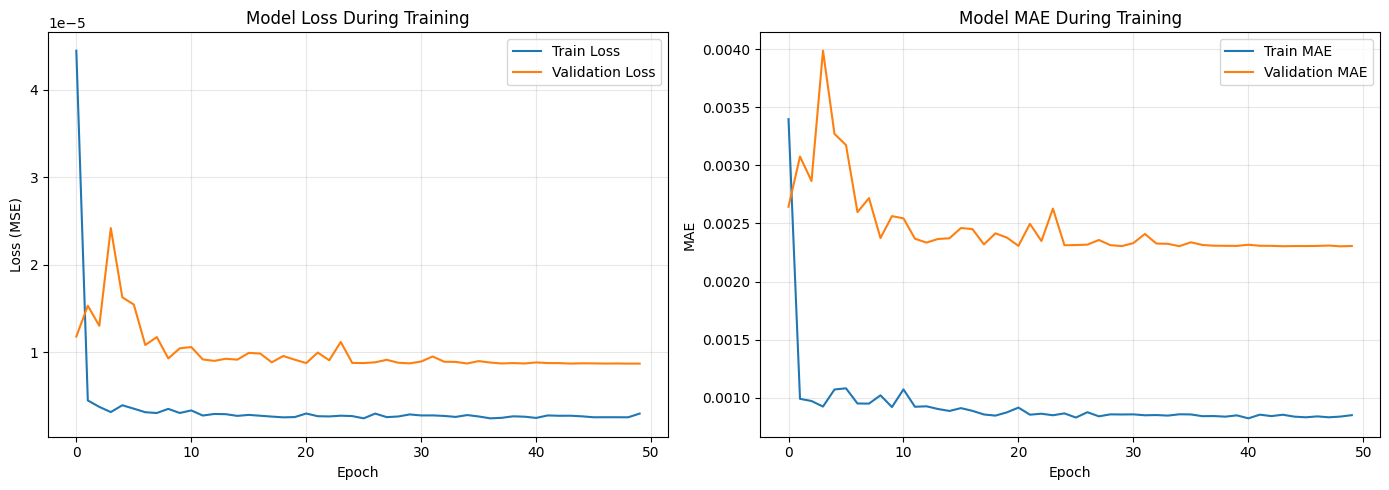

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Model Loss During Training')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['mae'], label='Train MAE')
ax2.plot(history.history['val_mae'], label='Validation MAE')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.set_title('Model MAE During Training')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

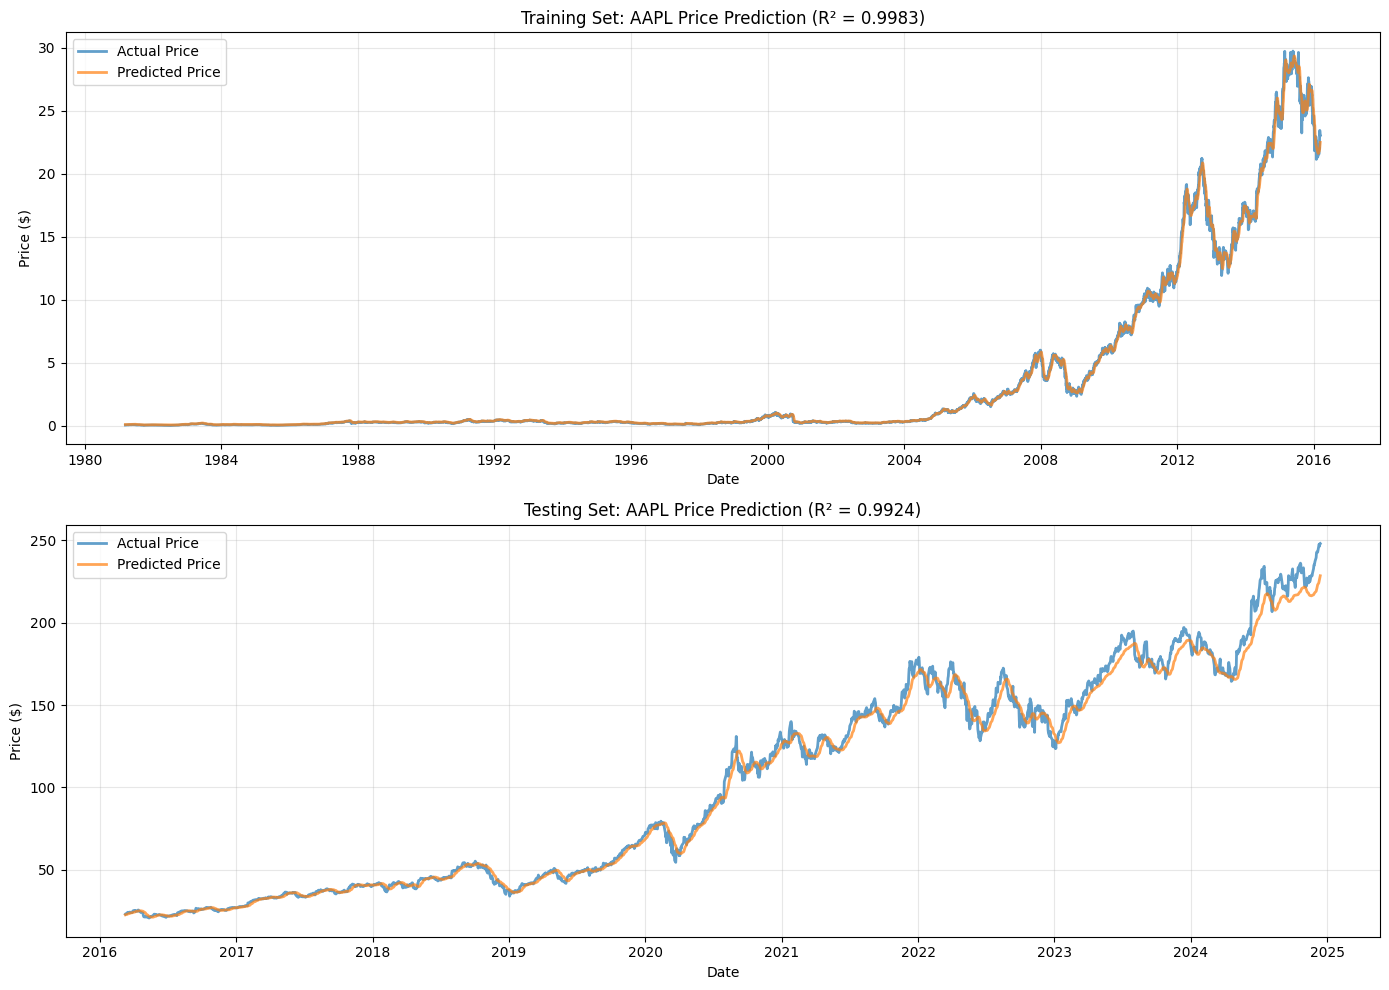

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Training predictions
train_dates = aapl['Date'].iloc[SEQ_LENGTH:SEQ_LENGTH+len(train_predictions)]
ax1.plot(train_dates, y_train_actual, label='Actual Price', alpha=0.7, linewidth=2)
ax1.plot(train_dates, train_predictions, label='Predicted Price', alpha=0.7, linewidth=2)
ax1.set_xlabel('Date')
ax1.set_ylabel('Price ($)')
ax1.set_title(f'Training Set: AAPL Price Prediction (R² = {train_metrics["R2"]:.4f})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Testing predictions
test_dates = aapl['Date'].iloc[SEQ_LENGTH+len(train_predictions):SEQ_LENGTH+len(train_predictions)+len(test_predictions)]
ax2.plot(test_dates, y_test_actual, label='Actual Price', alpha=0.7, linewidth=2)
ax2.plot(test_dates, test_predictions, label='Predicted Price', alpha=0.7, linewidth=2)
ax2.set_xlabel('Date')
ax2.set_ylabel('Price ($)')
ax2.set_title(f'Testing Set: AAPL Price Prediction (R² = {test_metrics["R2"]:.4f})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

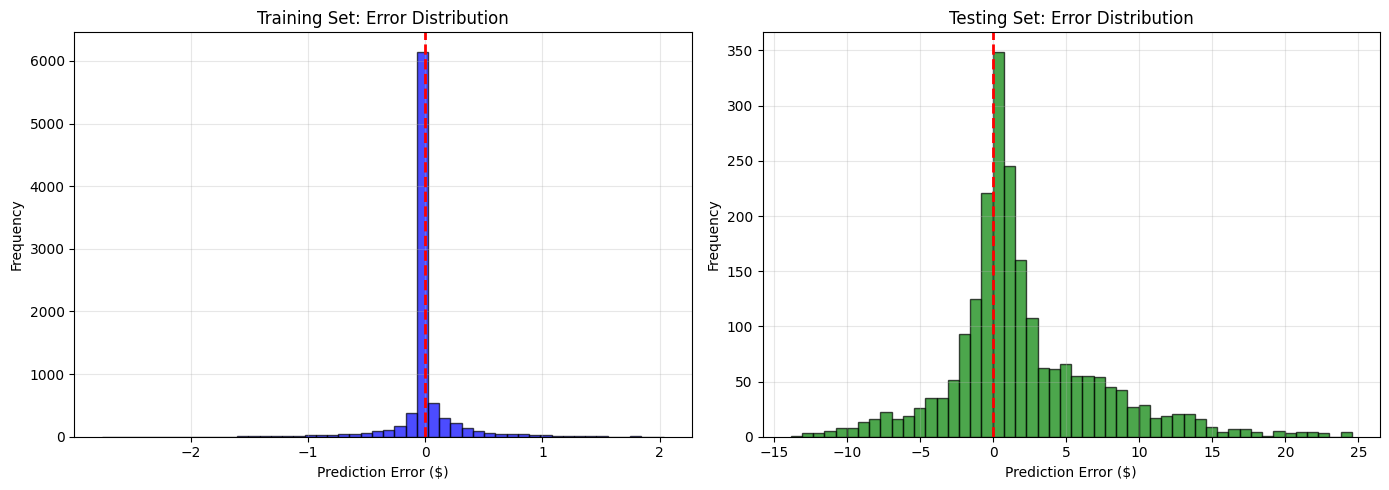

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

train_errors = y_train_actual - train_predictions
test_errors = y_test_actual - test_predictions

ax1.hist(train_errors, bins=50, alpha=0.7, color='blue', edgecolor='black')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Prediction Error ($)')
ax1.set_ylabel('Frequency')
ax1.set_title('Training Set: Error Distribution')
ax1.grid(True, alpha=0.3)

ax2.hist(test_errors, bins=50, alpha=0.7, color='green', edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Prediction Error ($)')
ax2.set_ylabel('Frequency')
ax2.set_title('Testing Set: Error Distribution')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

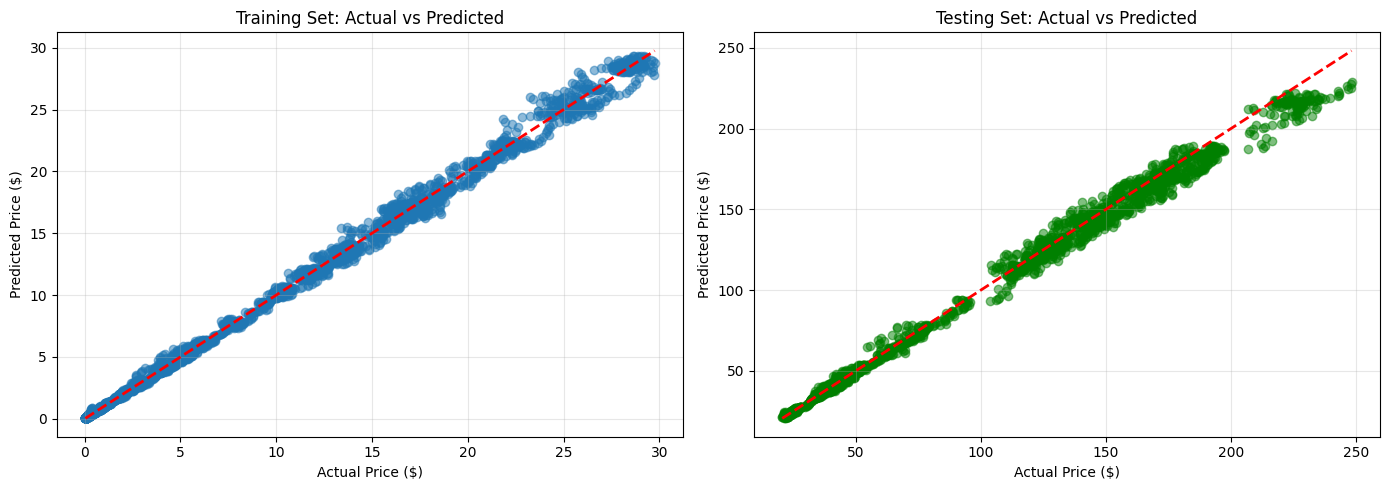

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(y_train_actual, train_predictions, alpha=0.5)
ax1.plot([y_train_actual.min(), y_train_actual.max()],
         [y_train_actual.min(), y_train_actual.max()],
         'r--', linewidth=2)
ax1.set_xlabel('Actual Price ($)')
ax1.set_ylabel('Predicted Price ($)')
ax1.set_title('Training Set: Actual vs Predicted')
ax1.grid(True, alpha=0.3)

ax2.scatter(y_test_actual, test_predictions, alpha=0.5, color='green')
ax2.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()],
         'r--', linewidth=2)
ax2.set_xlabel('Actual Price ($)')
ax2.set_ylabel('Predicted Price ($)')
ax2.set_title('Testing Set: Actual vs Predicted')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()